In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import acf as sm_acf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import ccf
import statsmodels.api as sm
np.random.seed(42)

## 1 – Stability

In [2]:
def sim_ar2(phi1, phi2, n=200, seed=42):
    rng = np.random.default_rng(seed)
    x = np.zeros(n)
    eps = rng.standard_normal(n)
    for t in range(2, n):
        x[t] = -phi1 * x[t-1] - phi2 * x[t-2] + eps[t]
    return x

def ar2_acf(phi1, phi2, maxlag=30):
    rho = np.zeros(maxlag + 1)
    rho[0] = 1.0
    rho[1] = -phi1 / (1 + phi2)
    for k in range(2, maxlag + 1):
        rho[k] = -phi1 * rho[k-1] - phi2 * rho[k-2]
    return rho

def ar2_roots(phi1, phi2):
    return np.roots([1, phi1, phi2])

def plot_ar2(phi1, phi2, label, maxlag=30):
    roots = ar2_roots(phi1, phi2)
    stat = np.all(np.abs(roots) > 1)
    tag = 'stationary' if stat else 'NON-stationary'
    print(f'{label}: φ₁={phi1}, φ₂={phi2} | roots={np.round(roots,4)} | |r|={np.round(np.abs(roots),4)} | {tag}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
    for i in range(5):
        x = sim_ar2(phi1, phi2, seed=42+i)
        axes[0].plot(x, alpha=0.6, linewidth=0.8)
    axes[0].set_title(f'{label}: 5 realizations (φ₁={phi1}, φ₂={phi2})')
    axes[0].set_xlabel('t'); axes[0].set_ylabel('X_t')

    rho_th = ar2_acf(phi1, phi2, maxlag)
    lags = np.arange(maxlag + 1)
    for i in range(5):
        x = sim_ar2(phi1, phi2, seed=42+i)
        acf_emp = sm_acf(x, nlags=maxlag)
        axes[1].plot(lags, acf_emp, 'o-', alpha=0.35, markersize=2, linewidth=0.7)
    axes[1].plot(lags, rho_th, 'k-', linewidth=1.5, label='ρ(k) theory')
    axes[1].axhline(0, color='gray', linewidth=0.3)
    axes[1].set_title(f'{label}: Empirical ACF vs ρ(k)')
    axes[1].set_xlabel('Lag k'); axes[1].legend(fontsize=8)
    for ax in axes: ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

### 1.1 & 1.2 — φ₁ = −0.6, φ₂ = 0.5

1.1–1.2: φ₁=-0.6, φ₂=0.5 | roots=[0.3+0.6403j 0.3-0.6403j] | |r|=[0.7071 0.7071] | NON-stationary


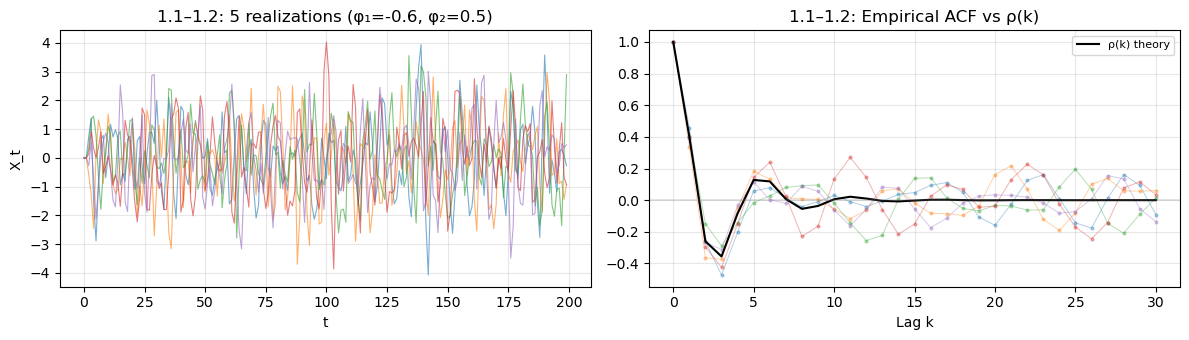

In [3]:
plot_ar2(-0.6, 0.5, '1.1–1.2')

### 1.3 — φ₁ = −0.6, φ₂ = −0.3

1.3: φ₁=-0.6, φ₂=-0.3 | roots=[ 0.9245 -0.3245] | |r|=[0.9245 0.3245] | NON-stationary


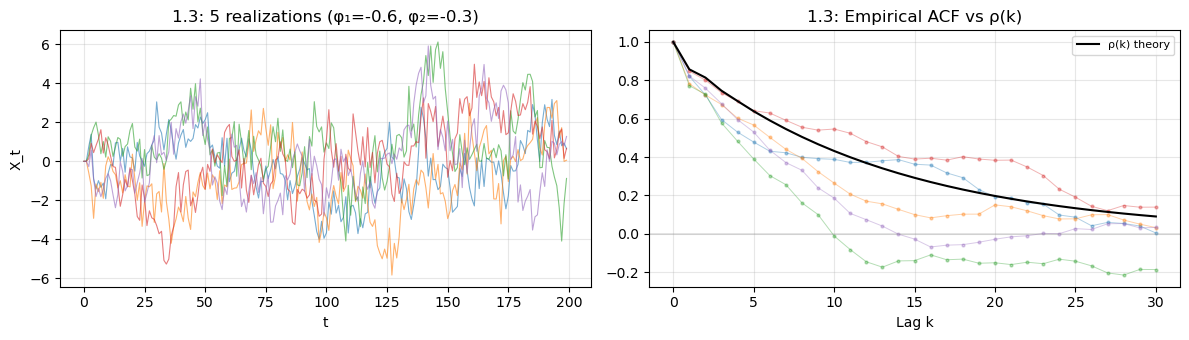

In [4]:
plot_ar2(-0.6, -0.3, '1.3')

### 1.4 — φ₁ = 0.6, φ₂ = −0.3

1.4: φ₁=0.6, φ₂=-0.3 | roots=[-0.9245  0.3245] | |r|=[0.9245 0.3245] | NON-stationary


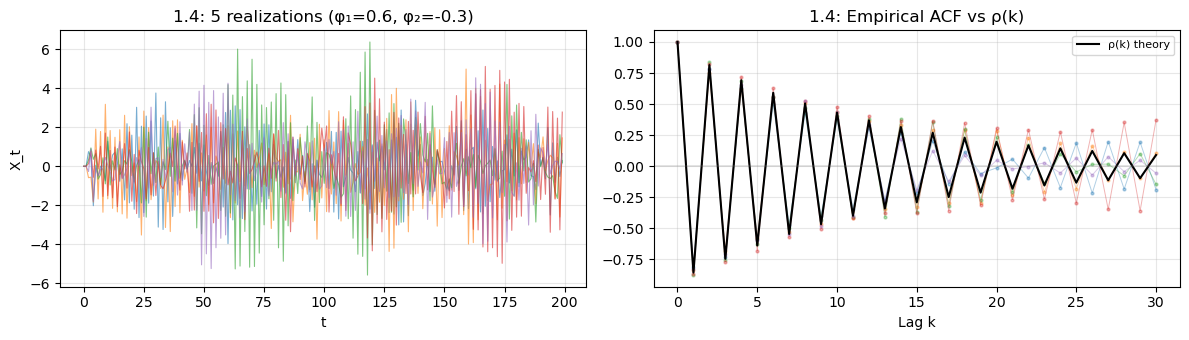

In [5]:
plot_ar2(0.6, -0.3, '1.4')

### 1.5 — φ₁ = −0.7, φ₂ = −0.3

1.5: φ₁=-0.7, φ₂=-0.3 | roots=[ 1.  -0.3] | |r|=[1.  0.3] | NON-stationary


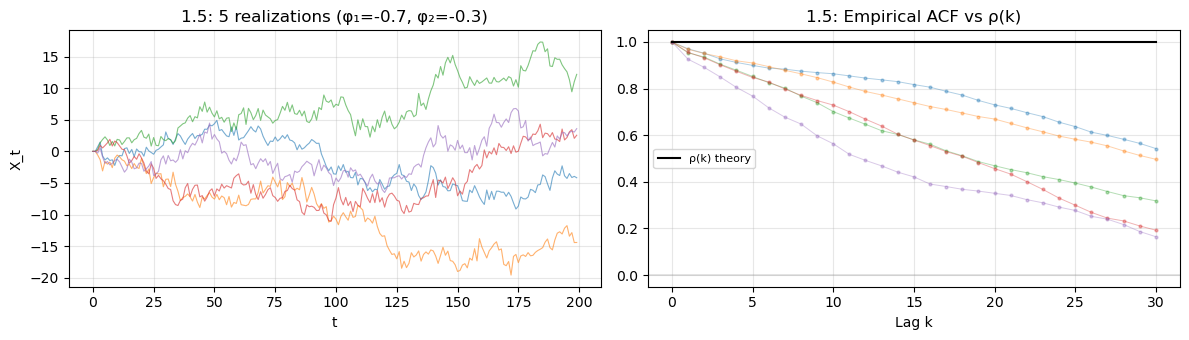

In [6]:
plot_ar2(-0.7, -0.3, '1.5')

### 1.6 — φ₁ = −0.75, φ₂ = −0.3

1.6: φ₁=-0.75, φ₂=-0.3 | roots=[ 1.0388 -0.2888] | |r|=[1.0388 0.2888] | NON-stationary


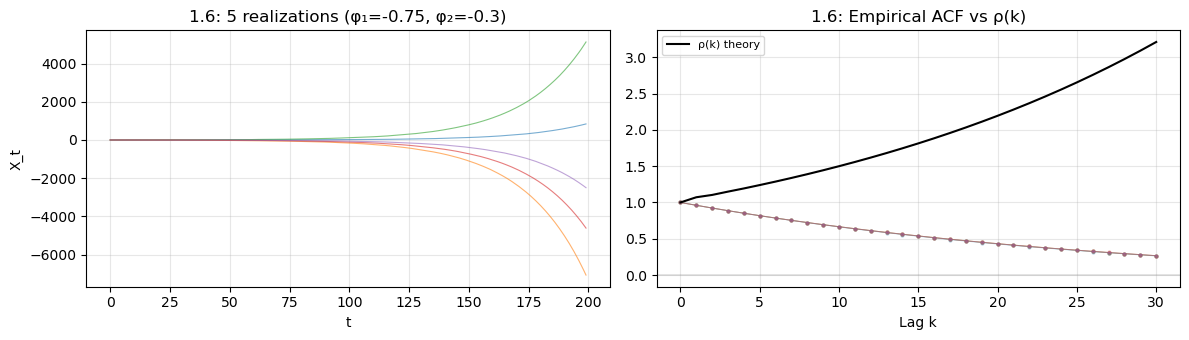

In [7]:
plot_ar2(-0.75, -0.3, '1.6')

## 2 – Predicting monthly solar power

In [8]:
solar = pd.read_csv('datasolar.csv')
Y = solar['power'].values
N_s = len(Y)

phi1_s = -0.38
Phi1_s = -0.94
mu_s = 5.72
sigma_eps = 0.22

X_s = np.log(Y) - mu_s

### 2.1 — Residuals & model validation

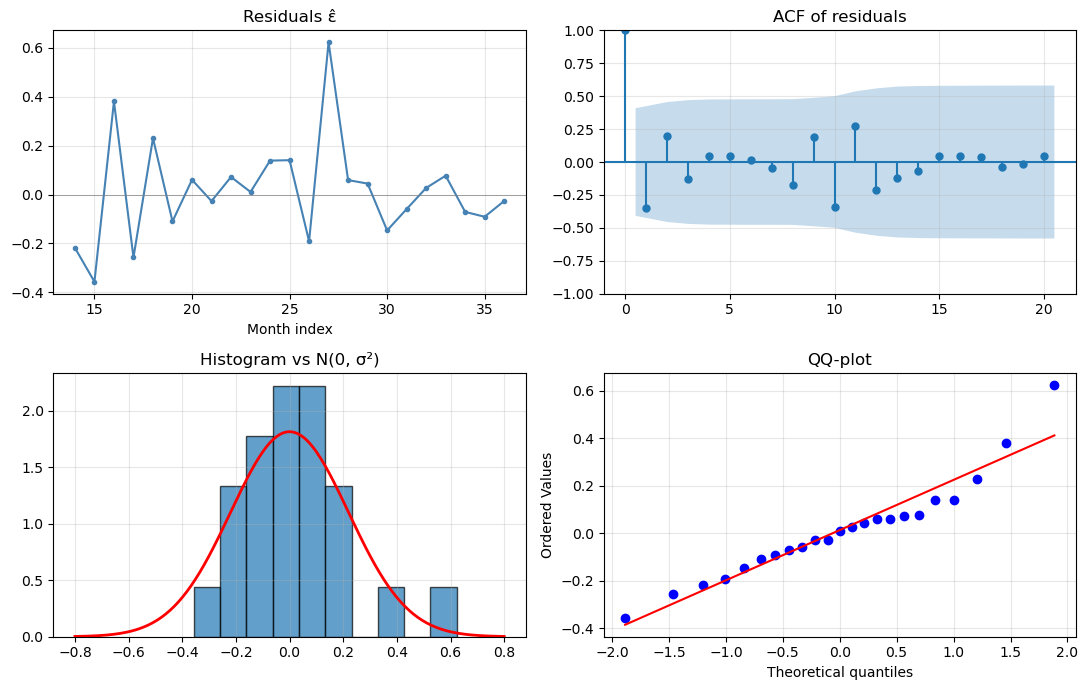

Jarque-Bera: stat=5.952, p=0.051
Residual mean=0.0134, std=0.2056


In [9]:
# Expanded model: X_t + phi1*X_{t-1} + Phi1*X_{t-12} + phi1*Phi1*X_{t-13} = eps_t
eps_hat = np.full(N_s, np.nan)
for t in range(13, N_s):
    eps_hat[t] = X_s[t] + phi1_s*X_s[t-1] + Phi1_s*X_s[t-12] + phi1_s*Phi1_s*X_s[t-13]
residuals_s = eps_hat[13:]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes[0,0].plot(np.arange(14, N_s+1), residuals_s, 'o-', markersize=3, color='steelblue')
axes[0,0].axhline(0, color='gray', linewidth=0.5)
axes[0,0].set_title('Residuals ε̂'); axes[0,0].set_xlabel('Month index')

plot_acf(residuals_s, lags=20, ax=axes[0,1], title='ACF of residuals')

axes[1,0].hist(residuals_s, bins=10, density=True, edgecolor='k', alpha=0.7)
xg = np.linspace(-0.8, 0.8, 200)
axes[1,0].plot(xg, stats.norm.pdf(xg, 0, sigma_eps), 'r-', linewidth=2)
axes[1,0].set_title('Histogram vs N(0, σ²)')

stats.probplot(residuals_s, dist='norm', plot=axes[1,1])
axes[1,1].set_title('QQ-plot')

for ax in axes.flat: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

jb = stats.jarque_bera(residuals_s)
print(f'Jarque-Bera: stat={jb.statistic:.3f}, p={jb.pvalue:.3f}')
print(f'Residual mean={np.mean(residuals_s):.4f}, std={np.std(residuals_s):.4f}')

### 2.2 & 2.3 — Forecast + 95% prediction intervals

  k |  Ŷ_{t+k|t}  |   Lower  |   Upper
------------------------------------------
  1 |      101.3 |     65.8 |    155.9
  2 |      147.2 |     92.8 |    233.5
  3 |      156.9 |     98.5 |    249.9
  4 |      142.6 |     89.4 |    227.2
  5 |      355.3 |    222.9 |    566.3
  6 |      538.0 |    337.6 |    857.5
  7 |      611.2 |    383.5 |    974.2
  8 |      631.9 |    396.5 |   1007.2
  9 |      630.1 |    395.3 |   1004.3
 10 |      508.2 |    318.8 |    809.9
 11 |      375.0 |    235.3 |    597.7
 12 |      280.5 |    176.0 |    447.1


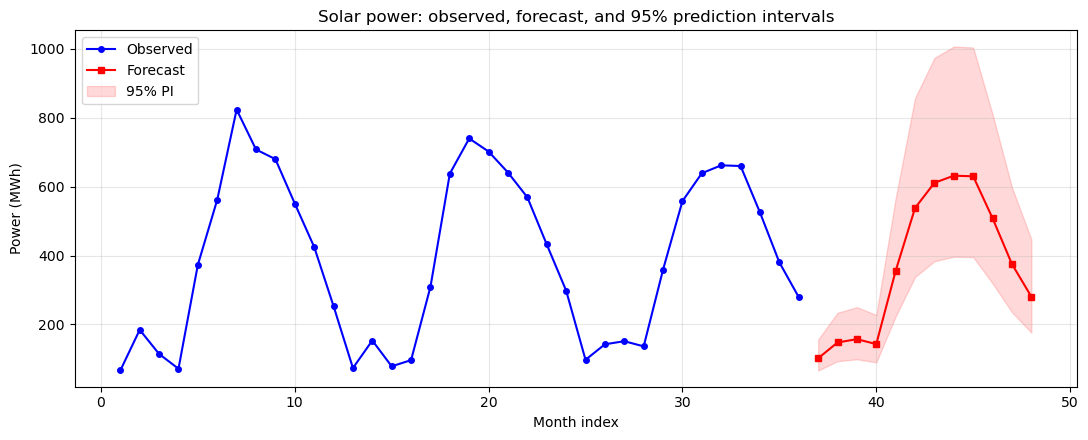

In [10]:
# Forecast X_{t+k|t}
X_ext = np.zeros(N_s + 12)
X_ext[:N_s] = X_s.copy()
for k in range(12):
    idx = N_s + k
    X_ext[idx] = -phi1_s*X_ext[idx-1] - Phi1_s*X_ext[idx-12] - phi1_s*Phi1_s*X_ext[idx-13]
X_pred = X_ext[N_s:]
Y_pred = np.exp(X_pred + mu_s)

# PI via AR(1) part: psi_j = (-phi1)^j
sigma2 = sigma_eps**2
var_X = np.array([sigma2 * sum((-phi1_s)**(2*j) for j in range(k)) for k in range(1, 13)])
se_X = np.sqrt(var_X)
z95 = 1.96
Y_lower = np.exp((X_pred - z95*se_X) + mu_s)
Y_upper = np.exp((X_pred + z95*se_X) + mu_s)

# Table
print('  k |  Ŷ_{t+k|t}  |   Lower  |   Upper')
print('-' * 42)
for k in range(12):
    print(f' {k+1:2d} | {Y_pred[k]:10.1f} | {Y_lower[k]:8.1f} | {Y_upper[k]:8.1f}')

# Plot
months = np.arange(1, N_s + 13)
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(months[:N_s], Y, 'bo-', markersize=4, label='Observed')
ax.plot(months[N_s:], Y_pred, 'rs-', markersize=5, label='Forecast')
ax.fill_between(months[N_s:], Y_lower, Y_upper, color='red', alpha=0.15, label='95% PI')
ax.set_xlabel('Month index'); ax.set_ylabel('Power (MWh)')
ax.set_title('Solar power: observed, forecast, and 95% prediction intervals')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 3 – ARX model for the heating of a box

### 3.1 — Plot the three time series

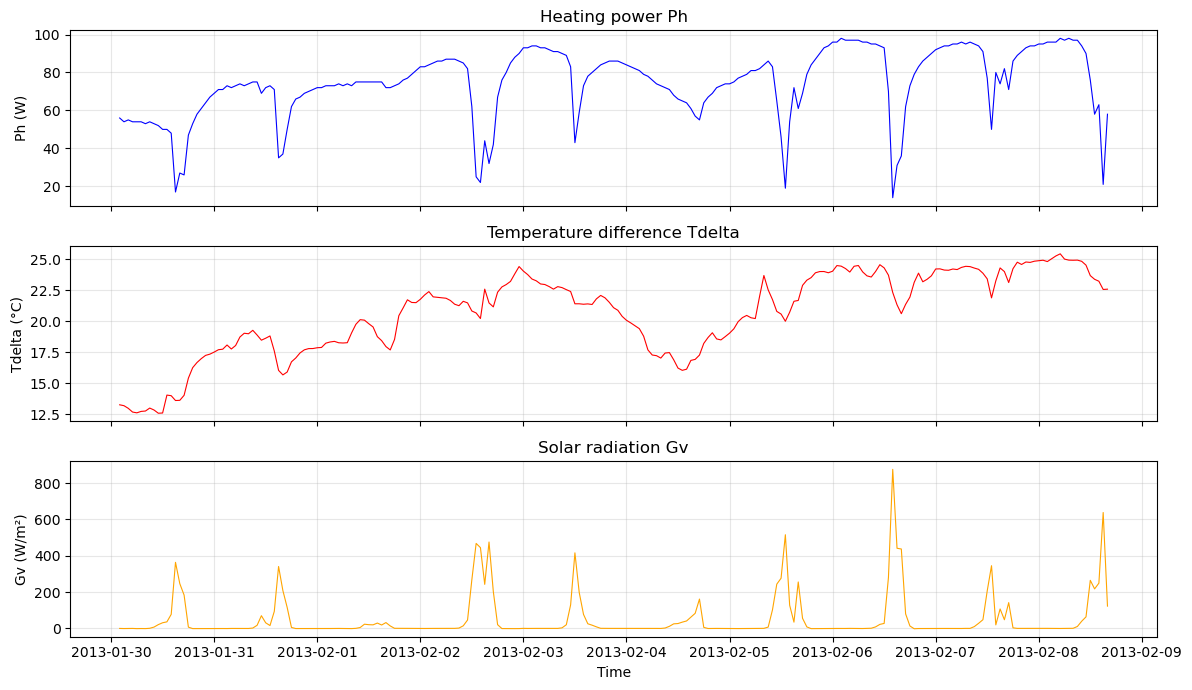

In [11]:
box = pd.read_csv('box_data_60min.csv')
box['tdate'] = pd.to_datetime(box['tdate'])

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(box['tdate'], box['Ph'], 'b-', linewidth=0.8)
axes[0].set_ylabel('Ph (W)'); axes[0].set_title('Heating power Ph')
axes[1].plot(box['tdate'], box['Tdelta'], 'r-', linewidth=0.8)
axes[1].set_ylabel('Tdelta (°C)'); axes[1].set_title('Temperature difference Tdelta')
axes[2].plot(box['tdate'], box['Gv'], color='orange', linewidth=0.8)
axes[2].set_ylabel('Gv (W/m²)'); axes[2].set_title('Solar radiation Gv')
axes[2].set_xlabel('Time')
for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 3.2 — Train / test split

In [12]:
split_date = pd.Timestamp('2013-02-06 00:00')
train = box[box['tdate'] <= split_date].copy()
test  = box[box['tdate'] > split_date].copy()
print(f'Train: {len(train)} rows  ({train["tdate"].iloc[0]} → {train["tdate"].iloc[-1]})')
print(f'Test:  {len(test)} rows  ({test["tdate"].iloc[0]} → {test["tdate"].iloc[-1]})')

Train: 167 rows  (2013-01-30 02:00:00 → 2013-02-06 00:00:00)
Test:  64 rows  (2013-02-06 01:00:00 → 2013-02-08 16:00:00)


### 3.3 — Exploratory: scatter, ACF, CCF

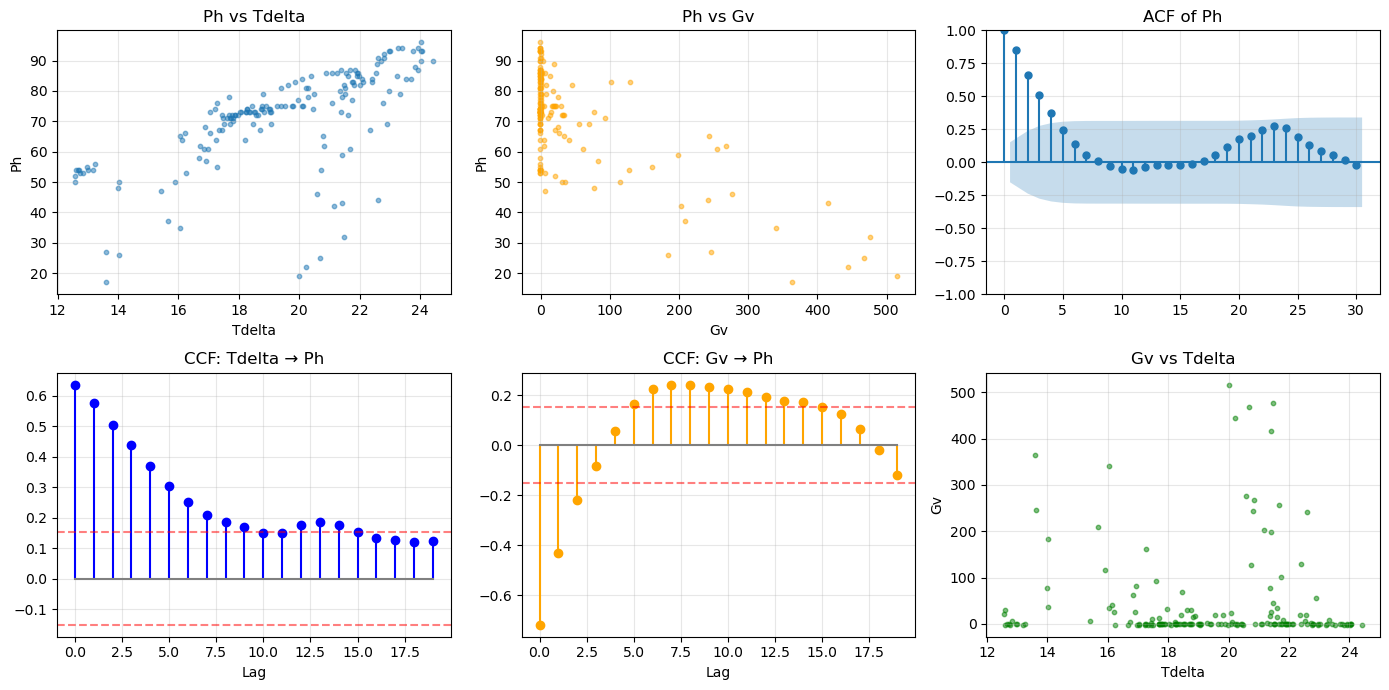

In [13]:
conf = 1.96 / np.sqrt(len(train))

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

axes[0,0].scatter(train['Tdelta'], train['Ph'], s=10, alpha=0.5)
axes[0,0].set_xlabel('Tdelta'); axes[0,0].set_ylabel('Ph'); axes[0,0].set_title('Ph vs Tdelta')

axes[0,1].scatter(train['Gv'], train['Ph'], s=10, alpha=0.5, color='orange')
axes[0,1].set_xlabel('Gv'); axes[0,1].set_ylabel('Ph'); axes[0,1].set_title('Ph vs Gv')

plot_acf(train['Ph'].values, lags=30, ax=axes[0,2], title='ACF of Ph')

ccf_td = ccf(train['Tdelta'].values, train['Ph'].values, nlags=20, alpha=None)
ccf_gv = ccf(train['Gv'].values, train['Ph'].values, nlags=20, alpha=None)
lags_c = np.arange(len(ccf_td))

axes[1,0].stem(lags_c, ccf_td, linefmt='b-', markerfmt='bo', basefmt='gray')
axes[1,0].axhline(conf, color='r', ls='--', alpha=0.5); axes[1,0].axhline(-conf, color='r', ls='--', alpha=0.5)
axes[1,0].set_title('CCF: Tdelta → Ph'); axes[1,0].set_xlabel('Lag')

axes[1,1].stem(lags_c, ccf_gv, linefmt='orange', markerfmt='o', basefmt='gray')
axes[1,1].axhline(conf, color='r', ls='--', alpha=0.5); axes[1,1].axhline(-conf, color='r', ls='--', alpha=0.5)
axes[1,1].set_title('CCF: Gv → Ph'); axes[1,1].set_xlabel('Lag')

axes[1,2].scatter(train['Tdelta'], train['Gv'], s=10, alpha=0.5, color='green')
axes[1,2].set_xlabel('Tdelta'); axes[1,2].set_ylabel('Gv'); axes[1,2].set_title('Gv vs Tdelta')

for ax in axes.flat: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 3.4 — Impulse response (up to lag 10)

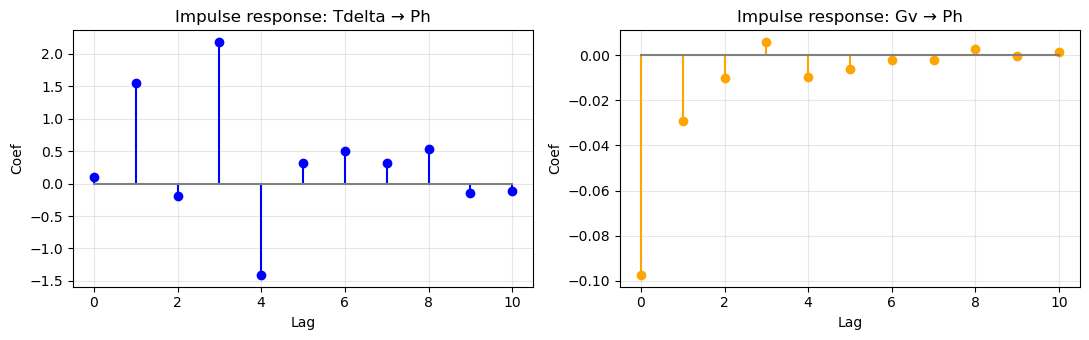

In [14]:
from sklearn.linear_model import LinearRegression

max_ir = 10
lag_cols_td = [f'Tdelta.l{l}' for l in range(max_ir+1)]
lag_cols_gv = [f'Gv.l{l}' for l in range(max_ir+1)]
sub_ir = train.dropna(subset=lag_cols_td + lag_cols_gv)
reg_ir = LinearRegression().fit(sub_ir[lag_cols_td + lag_cols_gv].values, sub_ir['Ph'].values)
ir_td = reg_ir.coef_[:max_ir+1]
ir_gv = reg_ir.coef_[max_ir+1:]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
lags_ir = np.arange(max_ir+1)
axes[0].stem(lags_ir, ir_td, linefmt='b-', markerfmt='bo', basefmt='gray')
axes[0].set_title('Impulse response: Tdelta → Ph'); axes[0].set_xlabel('Lag'); axes[0].set_ylabel('Coef')
axes[1].stem(lags_ir, ir_gv, linefmt='orange', markerfmt='o', basefmt='gray')
axes[1].set_title('Impulse response: Gv → Ph'); axes[1].set_xlabel('Lag'); axes[1].set_ylabel('Coef')
for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 3.5 — Linear regression: Ph = ω₁ Tdelta + ω₂ Gv + ε

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.994
Model:                            OLS   Adj. R-squared (uncentered):              0.994
Method:                 Least Squares   F-statistic:                          1.488e+04
Date:                Sat, 18 Apr 2026   Prob (F-statistic):                   4.76e-187
Time:                        15:31:19   Log-Likelihood:                         -518.81
No. Observations:                 167   AIC:                                      1042.
Df Residuals:                     165   BIC:                                      1048.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

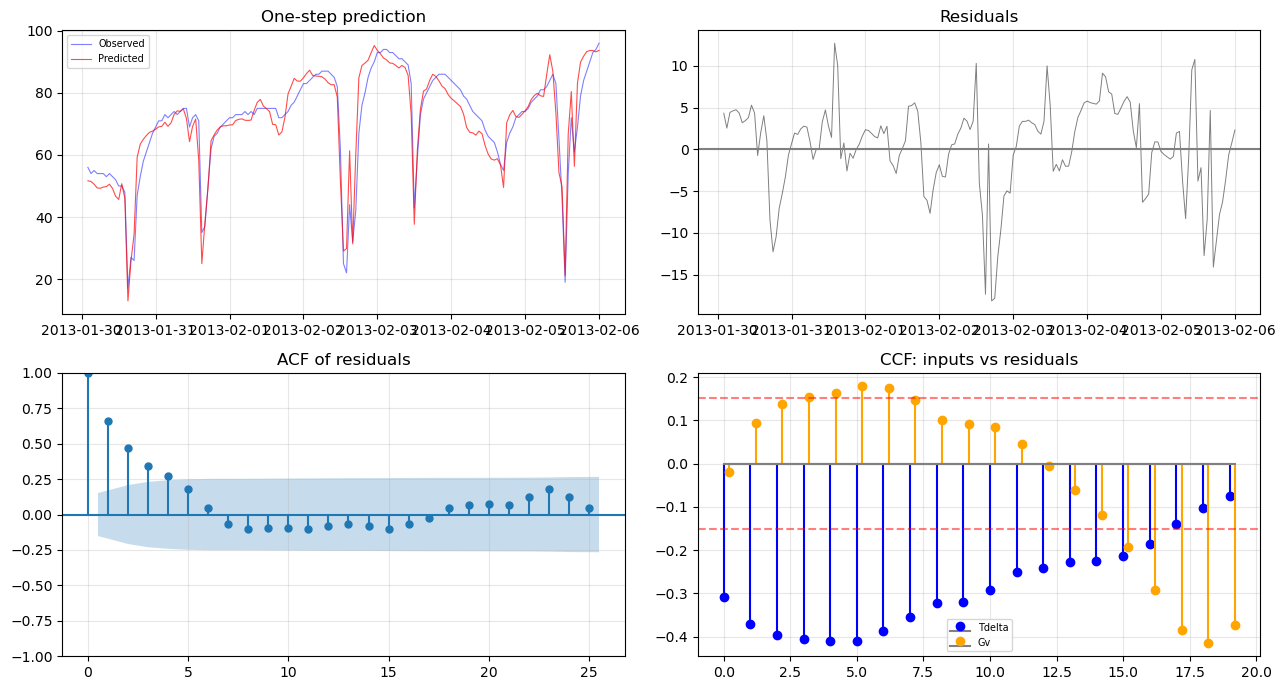

In [15]:
X_35 = train[['Tdelta', 'Gv']].values
y_35 = train['Ph'].values
model_35 = sm.OLS(y_35, X_35).fit()
y_hat_35 = model_35.predict(X_35)
res_35 = y_35 - y_hat_35
print(model_35.summary())

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes[0,0].plot(train['tdate'], y_35, 'b-', alpha=0.5, lw=0.8, label='Observed')
axes[0,0].plot(train['tdate'], y_hat_35, 'r-', alpha=0.7, lw=0.8, label='Predicted')
axes[0,0].set_title('One-step prediction'); axes[0,0].legend(fontsize=7)

axes[0,1].plot(train['tdate'], res_35, 'k-', alpha=0.5, lw=0.7)
axes[0,1].axhline(0, color='gray'); axes[0,1].set_title('Residuals')

plot_acf(res_35, lags=25, ax=axes[1,0], title='ACF of residuals')

ccf_r_td = ccf(train['Tdelta'].values, res_35, nlags=20, alpha=None)
ccf_r_gv = ccf(train['Gv'].values, res_35, nlags=20, alpha=None)
lc = np.arange(len(ccf_r_td))
axes[1,1].stem(lc, ccf_r_td, linefmt='b-', markerfmt='bo', basefmt='gray', label='Tdelta')
axes[1,1].stem(lc+0.2, ccf_r_gv, linefmt='orange', markerfmt='o', basefmt='gray', label='Gv')
axes[1,1].axhline(conf, color='r', ls='--', alpha=0.5); axes[1,1].axhline(-conf, color='r', ls='--', alpha=0.5)
axes[1,1].set_title('CCF: inputs vs residuals'); axes[1,1].legend(fontsize=7)

for ax in axes.flat: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### 3.6 — ARX(1)

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                          4.052e+04
Date:                Sat, 18 Apr 2026   Prob (F-statistic):                   4.24e-235
Time:                        15:31:19   Log-Likelihood:                         -401.13
No. Observations:                 167   AIC:                                      808.3
Df Residuals:                     164   BIC:                                      817.6
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

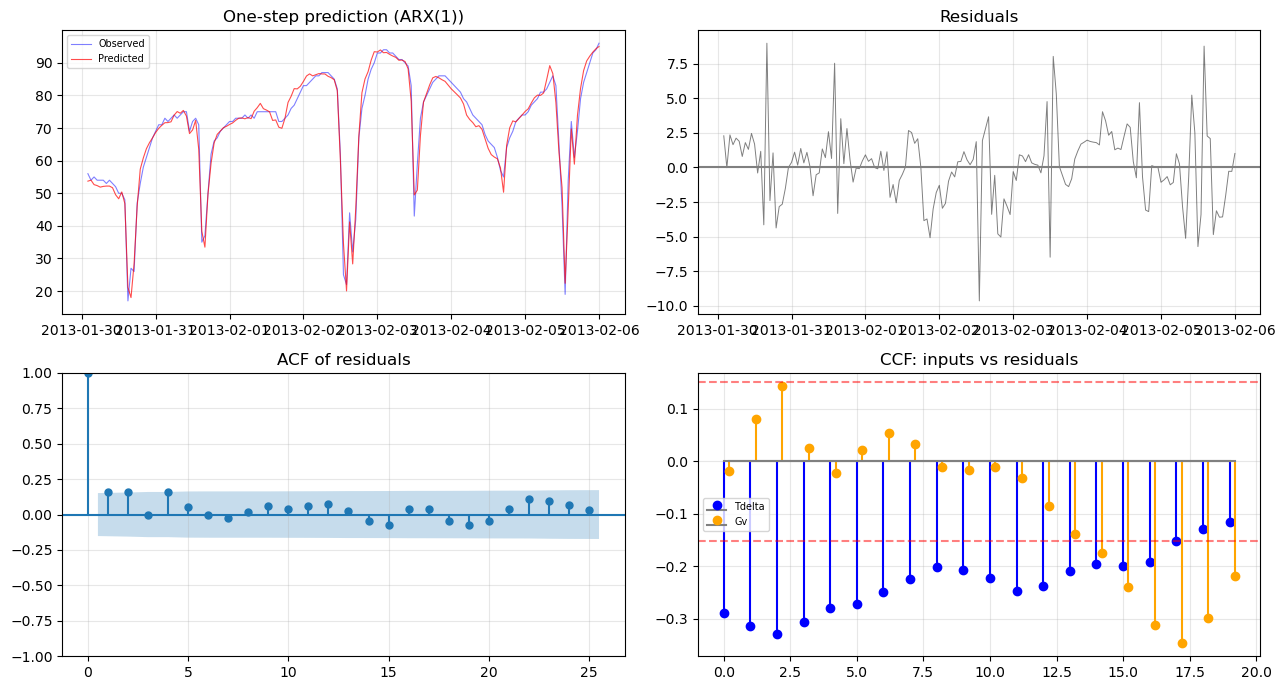


Residual std comparison: Lin.reg = 5.401,  ARX(1) = 2.670


In [16]:
X_36 = train[['Ph.l1', 'Tdelta.l0', 'Gv.l0']].values
y_36 = train['Ph'].values
model_36 = sm.OLS(y_36, X_36).fit()
y_hat_36 = model_36.predict(X_36)
res_36 = y_36 - y_hat_36
print(model_36.summary())

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes[0,0].plot(train['tdate'], y_36, 'b-', alpha=0.5, lw=0.8, label='Observed')
axes[0,0].plot(train['tdate'], y_hat_36, 'r-', alpha=0.7, lw=0.8, label='Predicted')
axes[0,0].set_title('One-step prediction (ARX(1))'); axes[0,0].legend(fontsize=7)

axes[0,1].plot(train['tdate'], res_36, 'k-', alpha=0.5, lw=0.7)
axes[0,1].axhline(0, color='gray'); axes[0,1].set_title('Residuals')

plot_acf(res_36, lags=25, ax=axes[1,0], title='ACF of residuals')

ccf_r_td36 = ccf(train['Tdelta'].values, res_36, nlags=20, alpha=None)
ccf_r_gv36 = ccf(train['Gv'].values, res_36, nlags=20, alpha=None)
axes[1,1].stem(lc, ccf_r_td36, linefmt='b-', markerfmt='bo', basefmt='gray', label='Tdelta')
axes[1,1].stem(lc+0.2, ccf_r_gv36, linefmt='orange', markerfmt='o', basefmt='gray', label='Gv')
axes[1,1].axhline(conf, color='r', ls='--', alpha=0.5); axes[1,1].axhline(-conf, color='r', ls='--', alpha=0.5)
axes[1,1].set_title('CCF: inputs vs residuals'); axes[1,1].legend(fontsize=7)

for ax in axes.flat: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'\nResidual std comparison: Lin.reg = {np.std(res_35):.3f},  ARX(1) = {np.std(res_36):.3f}')

### 3.7 — AIC & BIC vs model order

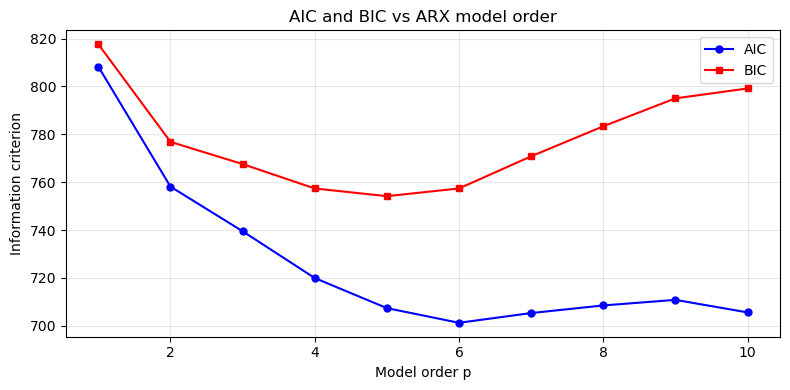

Best AIC: order 6
Best BIC: order 5


In [17]:
max_order = 10
aic_vals, bic_vals = [], []

for p in range(1, max_order + 1):
    cols = [f'Ph.l{l}' for l in range(1, p+1)] + \
           [f'Tdelta.l{l}' for l in range(p)] + \
           [f'Gv.l{l}' for l in range(p)]
    if not all(c in train.columns for c in cols):
        break
    sub = train[cols + ['Ph']].dropna()
    m = sm.OLS(sub['Ph'].values, sub[cols].values).fit()
    aic_vals.append(m.aic)
    bic_vals.append(m.bic)

orders = np.arange(1, len(aic_vals)+1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(orders, aic_vals, 'bo-', markersize=5, label='AIC')
ax.plot(orders, bic_vals, 'rs-', markersize=5, label='BIC')
ax.set_xlabel('Model order p'); ax.set_ylabel('Information criterion')
ax.set_title('AIC and BIC vs ARX model order')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Best AIC: order {orders[np.argmin(aic_vals)]}')
print(f'Best BIC: order {orders[np.argmin(bic_vals)]}')

### 3.8 — Test RMSE vs model order

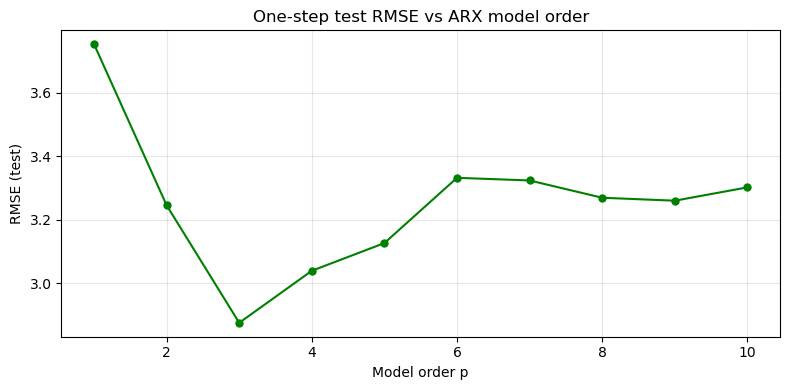

Best test RMSE: order 3, RMSE = 2.875


In [18]:
rmse_test = []

for p in range(1, max_order + 1):
    cols = [f'Ph.l{l}' for l in range(1, p+1)] + \
           [f'Tdelta.l{l}' for l in range(p)] + \
           [f'Gv.l{l}' for l in range(p)]
    if not all(c in train.columns for c in cols):
        break
    if not all(c in test.columns for c in cols):
        break
    m = sm.OLS(train[cols + ['Ph']].dropna()['Ph'].values,
               train[cols + ['Ph']].dropna()[cols].values).fit()
    sub_te = test[cols + ['Ph']].dropna()
    rmse_test.append(np.sqrt(np.mean((sub_te['Ph'].values - m.predict(sub_te[cols].values))**2)))

orders_r = np.arange(1, len(rmse_test)+1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(orders_r, rmse_test, 'go-', markersize=5)
ax.set_xlabel('Model order p'); ax.set_ylabel('RMSE (test)')
ax.set_title('One-step test RMSE vs ARX model order')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Best test RMSE: order {orders_r[np.argmin(rmse_test)]}, RMSE = {min(rmse_test):.3f}')

### 3.9 — Multi-step prediction (simulation)

Selected model order: p = 3
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.999
Model:                            OLS   Adj. R-squared (uncentered):              0.999
Method:                 Least Squares   F-statistic:                          2.112e+04
Date:                Sat, 18 Apr 2026   Prob (F-statistic):                   1.79e-238
Time:                        15:31:20   Log-Likelihood:                         -360.75
No. Observations:                 167   AIC:                                      739.5
Df Residuals:                     158   BIC:                                      767.6
Df Model:                           9                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------

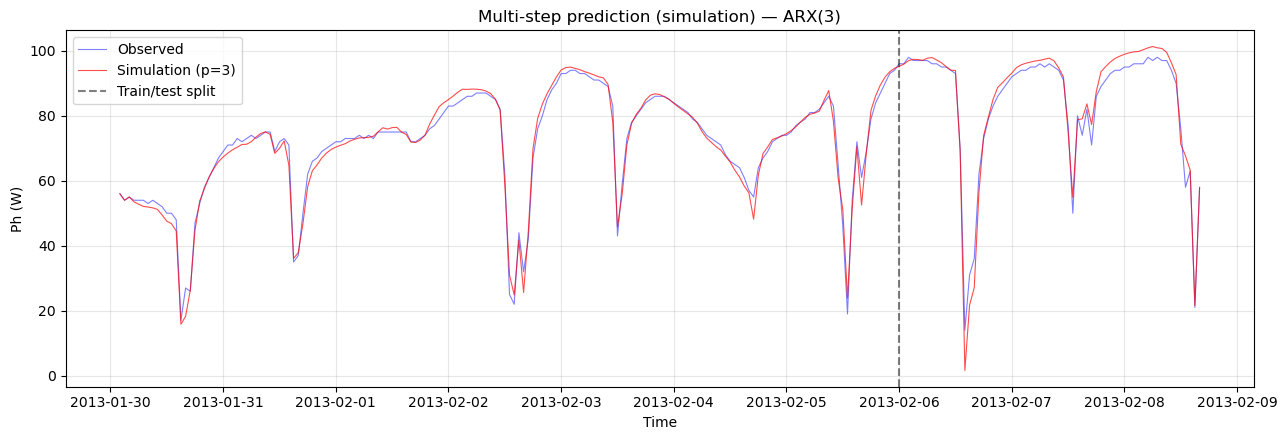

Simulation RMSE on test set: 3.669


In [19]:
best_p = 3  # minimum test RMSE in 3.8 (used for multi-step simulation here)
cols_best = [f'Ph.l{l}' for l in range(1, best_p+1)] + \
            [f'Tdelta.l{l}' for l in range(best_p)] + \
            [f'Gv.l{l}' for l in range(best_p)]
sub_tr = train[cols_best + ['Ph']].dropna()
model_best = sm.OLS(sub_tr['Ph'].values, sub_tr[cols_best].values).fit()
coefs = model_best.params
ar_c = coefs[:best_p]
td_c = coefs[best_p:2*best_p]
gv_c = coefs[2*best_p:]
print(f'Selected model order: p = {best_p}')
print(model_best.summary())

Ph_all = box['Ph'].values.astype(float)
Td_all = box['Tdelta'].values
Gv_all = box['Gv'].values
N_total = len(box)

Ph_sim = np.full(N_total, np.nan)
Ph_sim[:best_p] = Ph_all[:best_p]
for t in range(best_p, N_total):
    val = sum(ar_c[l-1]*Ph_sim[t-l] for l in range(1, best_p+1))
    val += sum(td_c[l]*Td_all[t-l] for l in range(best_p))
    val += sum(gv_c[l]*Gv_all[t-l] for l in range(best_p))
    Ph_sim[t] = val

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(box['tdate'], Ph_all, 'b-', alpha=0.5, lw=0.8, label='Observed')
ax.plot(box['tdate'], Ph_sim, 'r-', alpha=0.7, lw=0.8, label=f'Simulation (p={best_p})')
ax.axvline(split_date, color='k', ls='--', alpha=0.5, label='Train/test split')
ax.set_xlabel('Time'); ax.set_ylabel('Ph (W)')
ax.set_title(f'Multi-step prediction (simulation) — ARX({best_p})')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

rmse_sim = np.sqrt(np.mean((Ph_all[len(train):] - Ph_sim[len(train):])**2))
print(f'Simulation RMSE on test set: {rmse_sim:.3f}')

### 3.10 — Summary: one-step test predictions

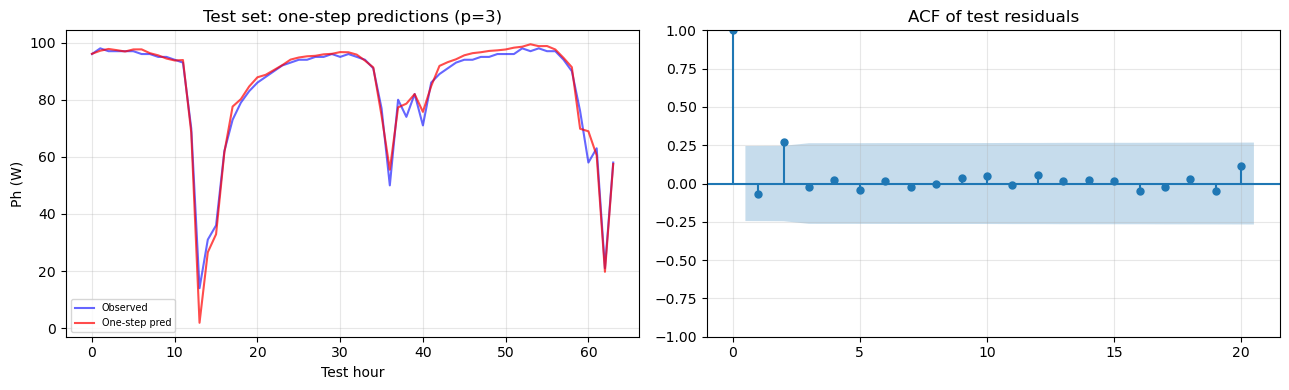

One-step test RMSE (p=3): 2.875
Simulation test RMSE (p=3): 3.669

RMSE summary for all orders (one-step test):
  p=1: RMSE=3.752
  p=2: RMSE=3.245
  p=3: RMSE=2.875
  p=4: RMSE=3.039
  p=5: RMSE=3.126
  p=6: RMSE=3.332
  p=7: RMSE=3.323
  p=8: RMSE=3.269
  p=9: RMSE=3.260
  p=10: RMSE=3.302


In [20]:
sub_te_best = test[cols_best + ['Ph']].dropna()
y_hat_te = model_best.predict(sub_te_best[cols_best].values)
res_te = sub_te_best['Ph'].values - y_hat_te
rmse_1step = np.sqrt(np.mean(res_te**2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(sub_te_best['Ph'].values, 'b-', alpha=0.6, label='Observed')
axes[0].plot(y_hat_te, 'r-', alpha=0.7, label='One-step pred')
axes[0].set_title(f'Test set: one-step predictions (p={best_p})')
axes[0].set_xlabel('Test hour'); axes[0].set_ylabel('Ph (W)'); axes[0].legend(fontsize=7)

plot_acf(res_te, lags=20, ax=axes[1], title='ACF of test residuals')

for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'One-step test RMSE (p={best_p}): {rmse_1step:.3f}')
print(f'Simulation test RMSE (p={best_p}): {rmse_sim:.3f}')
print(f'\nRMSE summary for all orders (one-step test):')
for p, r in zip(orders_r, rmse_test):
    print(f'  p={p}: RMSE={r:.3f}')